In [1]:
#load data
cedar_file = "../../processed/cedar_filtered.csv"
tcell_file = "../../processed/tcell_intermediate.csv"
mhc_file = "../../processed/mhc_intermediate.csv"

In [2]:
#load file

import pandas as pd 

with open(cedar_file, "r") as f: 
    first_line = f.readline() 
sep = "\t" if "\t" in first_line else ","

#read file
data = pd.read_csv(cedar_file, sep=sep, dtype=str)
data.head() 

,epitope_url,mt_seq,wt_seq,mutation,epitope_relation,source_molecule,label,has_wildtype,mt_length,wt_length
0,https://cedar.iedb.org/epitope/551,ACDPHSGHFV,ARDPHSGHFV,R24C,in-frame neo-epitope,NaN,1,True,10,10
1,https://cedar.iedb.org/epitope/3147,AMLGTHTMEV,AMLSPHAMDV,NaN,in-frame neo-epitope,NaN,1,True,10,10
2,https://cedar.iedb.org/epitope/14672,EVDPIGHLY,EVVPISHLY,NaN,in-frame neo-epitope,NaN,1,True,9,9
3,https://cedar.iedb.org/epitope/23214,GVYDGEEHSV,GAYDGEEH,NaN,in-frame neo-epitope,NaN,1,True,10,8
4,https://cedar.iedb.org/epitope/28958,ITKKVADLVGF,KKVADLI,NaN,in-frame neo-epitope,NaN,1,True,11,7


In [3]:
#make sure label is integer
data["label"] = pd.to_numeric(data["label"])

#extract epitope id
data["epitope_id"] = (data["epitope_url"].astype(str).str.split("/").str[-1])

print("CEDAR peptides loaded:", len(data))
print("Label distribution:", dict(data["label"].value_counts()))
data.head()

CEDAR peptides loaded: 6868
Label distribution: {0: 4937, 1: 1931}


,epitope_url,mt_seq,wt_seq,mutation,epitope_relation,source_molecule,label,has_wildtype,mt_length,wt_length,epitope_id
0,https://cedar.iedb.org/epitope/551,ACDPHSGHFV,ARDPHSGHFV,R24C,in-frame neo-epitope,NaN,1,True,10,10,551
1,https://cedar.iedb.org/epitope/3147,AMLGTHTMEV,AMLSPHAMDV,NaN,in-frame neo-epitope,NaN,1,True,10,10,3147
2,https://cedar.iedb.org/epitope/14672,EVDPIGHLY,EVVPISHLY,NaN,in-frame neo-epitope,NaN,1,True,9,9,14672
3,https://cedar.iedb.org/epitope/23214,GVYDGEEHSV,GAYDGEEH,NaN,in-frame neo-epitope,NaN,1,True,10,8,23214
4,https://cedar.iedb.org/epitope/28958,ITKKVADLVGF,KKVADLI,NaN,in-frame neo-epitope,NaN,1,True,11,7,28958


In [4]:
#load tcell df
tcell_df = pd.read_csv(tcell_file, sep=",", dtype=str)
print("loaded rows:", len(tcell_df))
tcell_df.head()

loaded rows: 153020


,Assay ID - CEDAR IRI,Reference - PMID,Epitope - CEDAR IRI,Epitope - Name,Epitope - Mutation,Epitope - Source Molecule,Related Object - Name,Related Object - Epitope Relation,Assay - Method,Assay - Response measured,Assay - Qualitative Measurement,Assay - Quantitative measurement,MHC Restriction - Name,MHC Restriction - Class,Effector Cell - Name,epitope_id
0,https://cedar.iedb.org/assay/29,15448372.0,https://cedar.iedb.org/epitope/31803,KLEDLERDL,NaN,large delta antigen,NaN,NaN,multimer/tetramer,qualitative binding,Positive,NaN,HLA-A*02:01,I,splenocyte,31803
1,https://cedar.iedb.org/assay/47,15519708.0,https://cedar.iedb.org/epitope/9203,DLMGYIPLV,NaN,Genome polyprotein,NaN,NaN,51 chromium,cytotoxicity,Positive,NaN,HLA-A*02:01,I,T cell,9203
2,https://cedar.iedb.org/assay/105,15448372.0,https://cedar.iedb.org/epitope/31803,KLEDLERDL,NaN,large delta antigen,NaN,NaN,multimer/tetramer,qualitative binding,Positive,NaN,HLA-A*02:01,I,T cell CD8+,31803
3,https://cedar.iedb.org/assay/107,15448372.0,https://cedar.iedb.org/epitope/31803,KLEDLERDL,NaN,large delta antigen,NaN,NaN,ELISPOT,IFNg release,Positive,NaN,HLA-A*02:01,I,PBMC,31803
4,https://cedar.iedb.org/assay/443,15104676.0,https://cedar.iedb.org/epitope/28958,ITKKVADLVGF,NaN,Melanoma-associated antigen 1,NaN,NaN,51 chromium,cytotoxicity,Positive,NaN,HLA-B*57:02,I,T cell,28958


In [5]:
##PULL RELEVANT COLUMNS FROM EACH TABLE
tcell = tcell_df[["epitope_id", "MHC Restriction - Name", "MHC Restriction - Class", "Assay - Qualitative Measurement", "Assay - Method"]].copy()
tcell.columns = ["epitope_id", "hla_allele", "hla_class", "assay_result", "assay_method"]
tcell.head()

,epitope_id,hla_allele,hla_class,assay_result,assay_method
0,31803,HLA-A*02:01,I,Positive,multimer/tetramer
1,9203,HLA-A*02:01,I,Positive,51 chromium
2,31803,HLA-A*02:01,I,Positive,multimer/tetramer
3,31803,HLA-A*02:01,I,Positive,ELISPOT
4,28958,HLA-B*57:02,I,Positive,51 chromium


In [33]:
##CLEAN HLA VALUES 
all_unique = set()
all_unique.update(tcell["hla_allele"].dropna().unique())
print("unique to inspect:", len(all_unique))
print(all_unique)

unique to inspect: 461
{'HLA-DRB1*01:03', 'HLA-B52', 'HLA-C*04:01', 'H2-i class I', 'HLA-B*50:01', 'HLA-A*68:01', 'HLA-A3', 'HLA-DPA1*01:03', 'HLA-A24', 'HLA-DRB1*16:01', 'HLA-B8', 'HLA-DRB4', 'HLA-A*02:03', 'HLA-A*02:01 K66A mutant', 'HLA-DRB4*01:03', 'HLA-DR8', 'HLA-DR17', 'HLA-DPw3', 'HLA-B38', 'HLA-A*02:24', 'HLA-B*42:01', 'HLA-B42', 'HLA-DRB1*04:02', 'HLA-DQB1*03:01', 'HLA-B*55:01', 'Patr-DQ', 'HLA-C*08:02', 'HLA-DR', 'HLA-A*02:01 T163A mutant', 'HLA-B57', 'HLA-DQA1*01:05/DQB1*05:01', 'RT1-B', 'HLA-Cw7', 'HLA-A*02:04', 'HLA class I', 'HLA-A*30:01', 'H2-q class II', 'HLA-B35', 'HLA-DQ5', 'Patr-B*03:01', 'HLA-DRB1*15:01', 'HLA-C*08:01', 'HLA-DRB1*03:17', 'HLA-A*02:01 A150P mutant', 'HLA-DR6', 'HLA-DR13', 'Caja-E', 'Patr-DRB1*10:01', 'HLA-B*81:01', 'H2-d class II', 'HLA-DQB1*06:03', 'HLA-DPB1*03:01', 'HLA-B62', 'HLA-DR1', 'HLA-A*02:06', 'HLA-DR12', 'HLA-DPB1*04:01', 'H2 class I', 'HLA-B*41:02', 'HLA-A*26:03', 'H2-Dk', 'HLA-B*40:03', 'HLA-B*07:05', 'HLA-DQB1*02:01', 'HLA-DRB1*01:01', 

In [34]:
import re 

#drop it/rename/keep 
drop = set() #replace with NaN 
rename = {} #old to new

for hla in all_unique: 
    if not isinstance(hla, str): 
        continue
    check = hla.strip()

    #DROP CLASS II 
    if "DR" in check or "DP" in check or "DQ" in check: 
        drop.add(hla)
        continue
    if "class ii" in check.lower(): 
        drop.add(hla)
        continue 

    #drop nonhuman 
    non_human = ("H2-", "H2 ", "Mamu-", "Patr-", "RT1-", "BoLA-", 
                 "DLA-", "Eqca-", "Caja", "Gogo-", "Papa-", "Ptal-", "Ovar-")
    if check.startswith(non_human): 
        drop.add(hla)
        continue 

    #drop vague entries (class I with no specific allele)
    if "class i" in check.lower() and "*" not in check: 
        drop.add(hla)
        continue

    #normalize old WHO format (remove w)
    w_match = re.match(r"^HLA-Cw(\d+)$", check)
    if w_match: 
        rename[hla] = f"HLA-C{w_match.group(1)}"
        continue

    #normalize 6 digit to 4
    long_match = re.match(r"^(HLA-[A-Z]+\*\d{2,3}:\d{2,3}):\d+", check)
    if long_match: 
        rename[hla] = long_match.group(1)
        continue 

    #remove any mutant suffix
    mutant_match = re.match(r"^(HLA-[A-Z]+\*\d{2,3}:\d{2,3}) .+mutant", check)
    if mutant_match: 
        rename[hla] = mutant_match.group(1)
        continue

    #ELSE keep as is (so keeps 4/2 digit)

print("drop:", len(drop))
print("rename:", len(rename))
print("keep:", len(all_unique) - len(drop) - len(rename))
    
    

drop: 244
rename: 20
keep: 197


In [35]:
#apply to tcell table 
tcell["hla_allele"] = tcell["hla_allele"].replace(rename)
tcell.loc[tcell["hla_allele"].isin(drop), "hla_allele"] = pd.NA

print("length before:")
print("tcell:", len(tcell))

#drop all NaNs
tcell = tcell.dropna(subset=["hla_allele"])

print("length after:")
print("tcell:", len(tcell))

length before:
tcell: 153020
length after:
tcell: 58954


In [36]:
#check before merging
print(tcell["hla_class"].value_counts())
print(tcell["assay_result"].value_counts())

tcell.head()

hla_class
I                58626
non classical      328
Name: count, dtype: int64
assay_result
Positive                 33260
Negative                 21661
Positive-Low              2779
Positive-High              948
Positive-Intermediate      306
Name: count, dtype: int64


,epitope_id,hla_allele,hla_class,assay_result,assay_method
0,31803,HLA-A*02:01,I,Positive,multimer/tetramer
1,9203,HLA-A*02:01,I,Positive,51 chromium
2,31803,HLA-A*02:01,I,Positive,multimer/tetramer
3,31803,HLA-A*02:01,I,Positive,ELISPOT
4,28958,HLA-B*57:02,I,Positive,51 chromium


In [37]:
#remove non classical values

tcell = tcell[tcell["hla_class"] == "I"]
tcell["hla_class"].value_counts()

hla_class
I    58626
Name: count, dtype: int64

In [43]:
#turn qualitative measurements into binary positive/negative
def is_positive(values): 
    for val in values: 
        if isinstance(val, str) and val.lower().startswith("positive"): 
            return True
    return False
    
#aggregate tcell by peptide hla
tcell_pair = tcell.groupby(["epitope_id", "hla_allele"]).agg(
    hla_class=("hla_class", "first"), 
    assay_any_positive=("assay_result", is_positive), 
    n_assays=("assay_result", "count")
).reset_index()
print(len(tcell_pair))
tcell_pair.head()

23884


,epitope_id,hla_allele,hla_class,assay_any_positive,n_assays
0,1000469,HLA-A*02:01,I,True,1
1,100124,HLA-B*08:01,I,True,6
2,10049,HLA-B27,I,False,1
3,100725,HLA-A*02:01,I,True,8
4,100725,HLA-A2,I,True,2


In [44]:
#save per pair tables
tcell_pair.to_csv("../../processed/tcell_pair.csv", index=False)

In [46]:
#ONE ROW PER PEPTIDE

def join_unique(values): 
    #sorts hlas and appends with semicolon
    uniques = sorted({val for val in values if isinstance(val, str)})
    return ";".join(uniques)

#tcell summary per peptide
tcell_peptide = tcell_pair.groupby("epitope_id").agg(
    hla_allele=("hla_allele", join_unique), 
    n_alleles=("hla_allele", "nunique"), 
    assay_any_positive=("assay_any_positive", "any"),
    n_assays_total=("n_assays", "sum")
).reset_index()
print("tcell summary peptides:", len(tcell_peptide))
tcell_peptide.head()

tcell summary peptides: 21328


,epitope_id,hla_allele,n_alleles,assay_any_positive,n_assays_total
0,1000469,HLA-A*02:01,1,True,1
1,100124,HLA-B*08:01,1,True,6
2,10049,HLA-B27,1,False,1
3,100725,HLA-A*02:01;HLA-A2,2,True,10
4,100843,HLA-A*02:01,1,True,7


In [47]:
#MERGE IN CEDAR BACKBONE
combined = data.merge(tcell_peptide, on="epitope_id", how="left")
combined.head()

,epitope_url,mt_seq,wt_seq,mutation,epitope_relation,source_molecule,label,has_wildtype,mt_length,wt_length,epitope_id,hla_allele,n_alleles,assay_any_positive,n_assays_total
0,https://cedar.iedb.org/epitope/551,ACDPHSGHFV,ARDPHSGHFV,R24C,in-frame neo-epitope,NaN,1,True,10,10,551,HLA-A*02:01;HLA-A2,2.0,True,10.0
1,https://cedar.iedb.org/epitope/3147,AMLGTHTMEV,AMLSPHAMDV,NaN,in-frame neo-epitope,NaN,1,True,10,10,3147,HLA-A*02:01,1.0,True,7.0
2,https://cedar.iedb.org/epitope/14672,EVDPIGHLY,EVVPISHLY,NaN,in-frame neo-epitope,NaN,1,True,9,9,14672,HLA-A*01:01;HLA-A*11:01;HLA-A1;HLA-B*35:01;HLA...,5.0,True,132.0
3,https://cedar.iedb.org/epitope/23214,GVYDGEEHSV,GAYDGEEH,NaN,in-frame neo-epitope,NaN,1,True,10,8,23214,HLA-A*02:01,1.0,True,11.0
4,https://cedar.iedb.org/epitope/28958,ITKKVADLVGF,KKVADLI,NaN,in-frame neo-epitope,NaN,1,True,11,7,28958,HLA-B*57:01;HLA-B*57:02,2.0,True,7.0


In [49]:
#summary stats

print("CEDAR rows:", len(data))
print("combined rows after merge:", len(combined))
print()
print("tcell hla filled:", combined["hla_allele"].notna().sum())
print("tcell hla missing:", combined["hla_allele"].isna().sum())

CEDAR rows: 6868
combined rows after merge: 6868

tcell hla filled: 6499
tcell hla missing: 369


In [50]:
#post combine hla filter
 #keep all 4 digit alleles 
    #if no 4 digit, fall back to 2
    #otherwise gives NaN 

def filter_hla(hla_str):
    #handle missing
    if not isinstance(hla_str, str) or hla_str.strip() == "":
        return pd.NA
    #split in single alleles
    parts = [part.strip() for part in hla_str.split(";")]

    #collect 4/2 digits
    four_digits = []
    two_digits = []
    for allele in parts: 
        #match 4 digit pattern
        if re.match(r"^HLA-[A-Z]+\*\d{2,3}:\d{2,3}$", allele): 
            if allele not in four_digits: 
                four_digits.append(allele)
        #match 2 digit
        elif re.match(r"^HLA-[A-Z]\d+$", allele): 
            if allele not in two_digits: 
                two_digits.append(allele)
        #everythign else gets dropped

    #prefer 4 digits
    if len(four_digits) > 0: 
        return ";".join(sorted(four_digits)) 
    #otherwise choose 2
    if len(two_digits) > 0: 
        return ";".join(sorted(two_digits))
    #otherwise NA
    return pd.NA
    
#apply to combined table 
combined["hla_allele"] = combined["hla_allele"].apply(filter_hla)
combined.head()


,epitope_url,mt_seq,wt_seq,mutation,epitope_relation,source_molecule,label,has_wildtype,mt_length,wt_length,epitope_id,hla_allele,n_alleles,assay_any_positive,n_assays_total
0,https://cedar.iedb.org/epitope/551,ACDPHSGHFV,ARDPHSGHFV,R24C,in-frame neo-epitope,NaN,1,True,10,10,551,HLA-A*02:01,2.0,True,10.0
1,https://cedar.iedb.org/epitope/3147,AMLGTHTMEV,AMLSPHAMDV,NaN,in-frame neo-epitope,NaN,1,True,10,10,3147,HLA-A*02:01,1.0,True,7.0
2,https://cedar.iedb.org/epitope/14672,EVDPIGHLY,EVVPISHLY,NaN,in-frame neo-epitope,NaN,1,True,9,9,14672,HLA-A*01:01;HLA-A*11:01;HLA-B*35:01;HLA-C*05:01,5.0,True,132.0
3,https://cedar.iedb.org/epitope/23214,GVYDGEEHSV,GAYDGEEH,NaN,in-frame neo-epitope,NaN,1,True,10,8,23214,HLA-A*02:01,1.0,True,11.0
4,https://cedar.iedb.org/epitope/28958,ITKKVADLVGF,KKVADLI,NaN,in-frame neo-epitope,NaN,1,True,11,7,28958,HLA-B*57:01;HLA-B*57:02,2.0,True,7.0


In [51]:
#inspect columns to check if everything was achieved
print(combined.columns) 


Index(['epitope_url', 'mt_seq', 'wt_seq', 'mutation', 'epitope_relation',
       'source_molecule', 'label', 'has_wildtype', 'mt_length', 'wt_length',
       'epitope_id', 'hla_allele', 'n_alleles', 'assay_any_positive',
       'n_assays_total'],
      dtype='object')


In [52]:
print(combined["hla_allele"].unique())

['HLA-A*02:01' 'HLA-A*01:01;HLA-A*11:01;HLA-B*35:01;HLA-C*05:01'
 'HLA-B*57:01;HLA-B*57:02' 'HLA-A*24:02' 'HLA-A*03:01;HLA-A*11:01'
 'HLA-B*44:03' 'HLA-B*15:01' 'HLA-B*07:02' 'HLA-B*44:02' 'HLA-B*38:01'
 'HLA-C*14:02' 'HLA-A*03:01' 'HLA-B*27:05' 'HLA-B*44:02;HLA-B*44:03'
 'HLA-A*11:01' 'HLA-A28' 'HLA-A*68:02' 'HLA-A*01:01'
 'HLA-A*01:01;HLA-B*15:01' 'HLA-B*52:01' 'HLA-A*02:05' 'HLA-C*06:02'
 'HLA-A*02:01;HLA-A*24:02;HLA-B*07:02' 'HLA-A*02:01;HLA-A*24:02'
 'HLA-A*02:01;HLA-B*07:02' 'HLA-A*30:01' 'HLA-B*08:01' 'HLA-B*13:02'
 'HLA-B*51:01' 'HLA-C*05:01' 'HLA-A*02:03' 'HLA-A*02:01;HLA-A*02:03'
 'HLA-C*03:03' 'HLA-A*30:02' 'HLA-A*25:01' 'HLA-A*23:01;HLA-B*27:05'
 'HLA-A*02:11' 'HLA-A*02:01;HLA-A*02:06' 'HLA-C*07:02' 'HLA-A*31:01'
 'HLA-A*11:01;HLA-A*31:01' 'HLA-B*35:01' 'HLA-C*01:02' 'HLA-B*35:03'
 'HLA-A*68:01' 'HLA-C*14:03' 'HLA-C*05:01;HLA-C*08:02'
 'HLA-B*07:02;HLA-C*03:04;HLA-C*05:01;HLA-C*08:02' 'HLA-B*39:01'
 'HLA-B*18:01' 'HLA-C*07:01' 'HLA-C*04:01' 'HLA-B*44:03;HLA-B*44:08'
 'HLA-A

In [53]:
#drop na rows
print("before dropping na rows:", len(combined))
combined = combined.dropna(subset=["hla_allele"])
print("after dropping na rows:", len(combined))

before dropping na rows: 6868
after dropping na rows: 6499


In [ ]:
#checking tcell label against cedar
crosscheck = pd.crosstab(combined["label"], combined["assay_any_positive"], dropna=False)
print(crosscheck) #18 odd cases where cedar is neg but tcell is pos, but cedar is curated so can be trusted

assay_any_positive  False  True 
label                           
0                    4581     18
1                       0   1900


In [59]:
### HLA DISTRIBUTION

#count tcell hla alleles 
tcell_hlas = [] 

#loop thru all nonempty 
for cell in combined["hla_allele"].dropna():  #skip with no tcell hla 
    #split by ; 
    alleles = cell.split(";")
    for allele in alleles: 
        tcell_hlas.append(allele.strip())
        
#count how often each 
tcell_counts = pd.Series(tcell_hlas).value_counts()
print("top 10 tcell hla alleles")
print(tcell_counts.head(10))

top 10 tcell hla alleles
HLA-A*02:01    1809
HLA-A*11:01     514
HLA-A*24:02     474
HLA-B*07:02     434
HLA-A*03:01     394
HLA-A*01:01     330
HLA-B*15:01     235
HLA-B*08:01     181
HLA-B*35:01     170
HLA-A*23:01     113
Name: count, dtype: int64


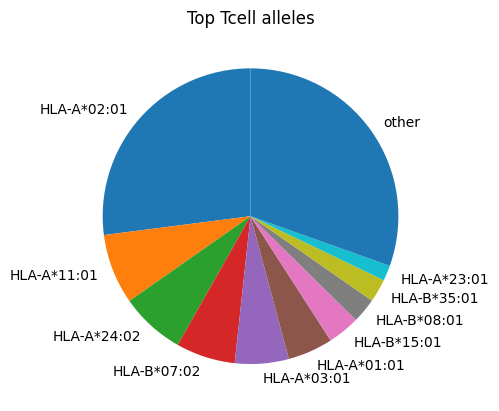

In [60]:
##PIE CHART 
tcell_top = tcell_counts.head(10).copy()

#sum of remaining
tcell_other = tcell_counts.iloc[10:].sum()
if tcell_other > 0:
    tcell_top["other"] = tcell_other

#plot chart
import matplotlib.pyplot as plt
plt.pie(tcell_top.values, 
        labels=tcell_top.index, startangle=90)
plt.title("Top Tcell alleles")
plt.show()

Tcell distribution:
1    6322
2     165
3       9
4       3
Name: count, dtype: int64


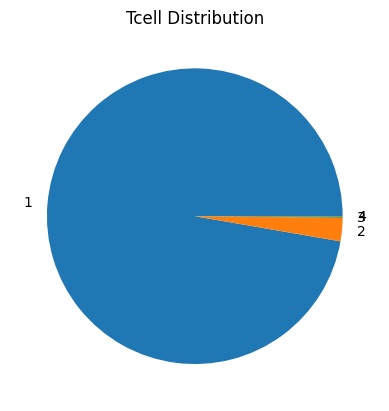

In [63]:
#HOW MANY EACH PEPTIDE 

tcell_per_peptide = [] 
for cell in combined["hla_allele"]: 
    if pd.isna(cell): 
        tcell_per_peptide.append(0)
    else: 
        n = len(cell.split(";")) 
        tcell_per_peptide.append(n)

#turn into counts
#how many peptides have 0/1/2/ etc HLAs
tcell_dist = pd.Series(tcell_per_peptide).value_counts().sort_index()

print("Tcell distribution:")
print(tcell_dist)

#pie chart
plt.pie(tcell_dist.values, labels=tcell_dist.index)
plt.title("Tcell Distribution")
plt.show()

In [65]:
combined.head()

,epitope_url,mt_seq,wt_seq,mutation,epitope_relation,source_molecule,label,has_wildtype,mt_length,wt_length,epitope_id,hla_allele,n_alleles,assay_any_positive,n_assays_total
0,https://cedar.iedb.org/epitope/551,ACDPHSGHFV,ARDPHSGHFV,R24C,in-frame neo-epitope,NaN,1,True,10,10,551,HLA-A*02:01,2.0,True,10.0
1,https://cedar.iedb.org/epitope/3147,AMLGTHTMEV,AMLSPHAMDV,NaN,in-frame neo-epitope,NaN,1,True,10,10,3147,HLA-A*02:01,1.0,True,7.0
2,https://cedar.iedb.org/epitope/14672,EVDPIGHLY,EVVPISHLY,NaN,in-frame neo-epitope,NaN,1,True,9,9,14672,HLA-A*01:01;HLA-A*11:01;HLA-B*35:01;HLA-C*05:01,5.0,True,132.0
3,https://cedar.iedb.org/epitope/23214,GVYDGEEHSV,GAYDGEEH,NaN,in-frame neo-epitope,NaN,1,True,10,8,23214,HLA-A*02:01,1.0,True,11.0
4,https://cedar.iedb.org/epitope/28958,ITKKVADLVGF,KKVADLI,NaN,in-frame neo-epitope,NaN,1,True,11,7,28958,HLA-B*57:01;HLA-B*57:02,2.0,True,7.0


In [64]:
#save
combined.to_csv("../../processed/cedar_final.csv", index=False)